## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [10]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Answers:**


1.   Regression predicts a continuous numeric outcome, while classifications predicts a discrete class label.
2.   A confusion matrix is a table that compares actual vs. predicted class labels. It shows counts of true or false positives and negatives that help us understand where the model is making certain mistakes.
3. Accuracy is the proportion of predictions that a model gets correct (correct predictions/total predictions). It can be insufficient if classes are imbalanced and it does not distinguish between error types.
4. RMSE measures the typical size of prediction errors in regression. It is the squared root of the average squared difference between predicted and actual values.
5. Overfitting is when a model is too complex and learns noise in the training data. Underfitting is a when a model is too simple to capture the true pattern of the data.
6. Splitting the data helps ensure that we evaluate the model on unseen data, which gives a realistic measure of generalization. Choosing k based on test accuracy helps balance bias and prevent overfitting.
7. Pedicting class labels strengths include simple to interpret and direct decision output. Weaknesses are less flexible for risk-sensitive decisions. Predicting probabilities strengths include risk management and model confidence. Weaknesses are harder to interpret.






**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [44]:
#Q2.1

import pandas as pd

df = pd.read_csv('data/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [45]:
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nMissing values:\n", df.isna().sum())

Shape: (338, 4)

Head:
     voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

Missing values:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64


In [46]:
print("\nMine type counts:\n", df["mine_type"].value_counts().sort_index())


Mine type counts:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


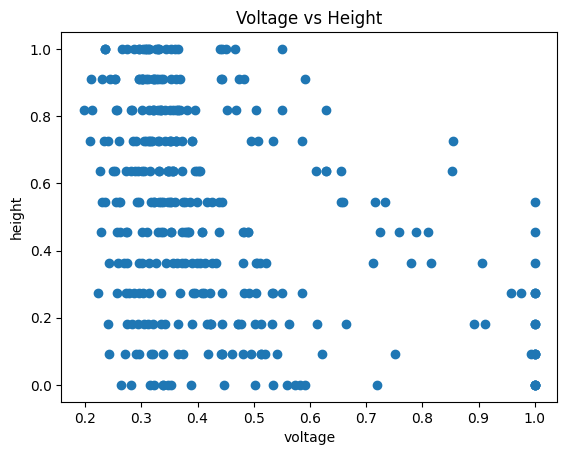

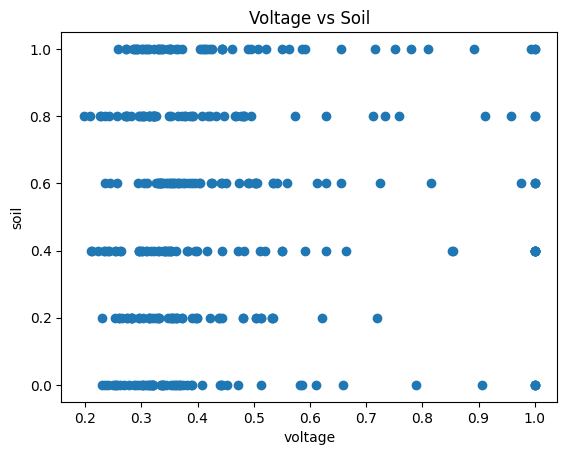

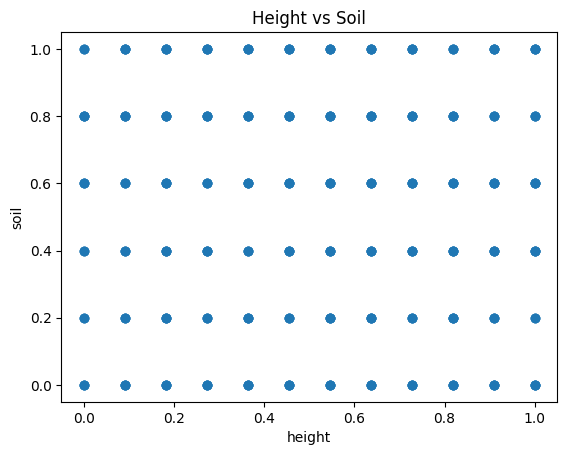

In [47]:
plt.figure()
plt.scatter(df["voltage"], df["height"])
plt.xlabel("voltage")
plt.ylabel("height")
plt.title("Voltage vs Height")
plt.show()

plt.figure()
plt.scatter(df["voltage"], df["soil"])
plt.xlabel("voltage")
plt.ylabel("soil")
plt.title("Voltage vs Soil")
plt.show()

plt.figure()
plt.scatter(df["height"], df["soil"])
plt.xlabel("height")
plt.ylabel("soil")
plt.title("Height vs Soil")
plt.show()

In [48]:
#Q2.2

X = df[["voltage", "height", "soil"]].copy()
y = df["mine_type"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain class counts:\n", y_train.value_counts().sort_index())
print("\nTest class counts:\n", y_test.value_counts().sort_index())

Train shape: (169, 3) Test shape: (169, 3)

Train class counts:
 mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test class counts:
 mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


Best k = 1
Test Accuracy at best k = 0.4615


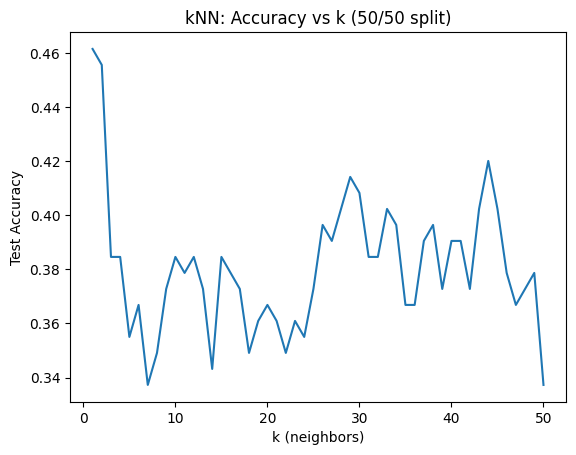

In [49]:
#Q2.3

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

k_grid = list(range(1, 51))
accs = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    accs.append(accuracy_score(y_test, preds))

best_k = k_grid[int(np.argmax(accs))]
best_acc = float(np.max(accs))

print(f"Best k = {best_k}")
print(f"Test Accuracy at best k = {best_acc:.4f}")

plt.figure()
plt.plot(k_grid, accs)
plt.xlabel("k (neighbors)")
plt.ylabel("Test Accuracy")
plt.title("kNN: Accuracy vs k (50/50 split)")
plt.show()

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)

Confusion matrix (rows=actual, cols=predicted):
 [[21  0  4  4  7]
 [ 0 32  0  3  0]
 [ 8  0  7 10  8]
 [ 7  5  4 11  6]
 [ 7  0  9  9  7]]

Overall accuracy: 0.46153846153846156

Confusion table:

          pred_1  pred_2  pred_3  pred_4  pred_5
actual_1      21       0       4       4       7
actual_2       0      32       0       3       0
actual_3       8       0       7      10       8
actual_4       7       5       4      11       6
actual_5       7       0       9       9       7


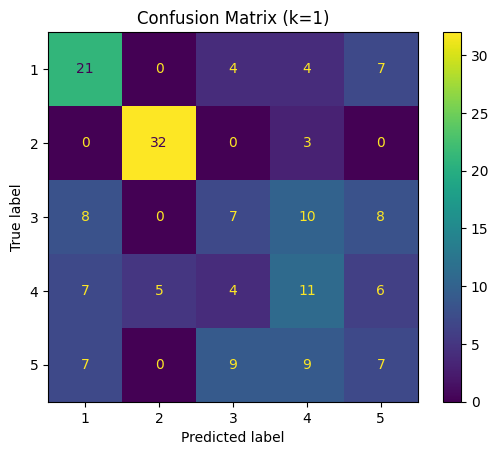


Per-class recall (higher = more accurate for that class):

 mine_type   recall
         1 0.583333
         2 0.914286
         3 0.212121
         4 0.333333
         5 0.218750

Top confusions (true -> predicted, count):
3 -> 4: 10
5 -> 3: 9
5 -> 4: 9
3 -> 1: 8
3 -> 5: 8
1 -> 5: 7
4 -> 1: 7
5 -> 1: 7
4 -> 5: 6
4 -> 2: 5


In [50]:
#Q2.4

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion matrix (rows=actual, cols=predicted):\n", cm)
print("\nOverall accuracy:", accuracy_score(y_test, y_pred))

cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
print("\nConfusion table:\n")
print(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

per_class_recall = cm.diagonal() / cm.sum(axis=1)
recall_df = pd.DataFrame({"mine_type": labels, "recall": per_class_recall})
print("\nPer-class recall (higher = more accurate for that class):\n")
print(recall_df.to_string(index=False))

confusions = []
for i, true_lab in enumerate(labels):
    for j, pred_lab in enumerate(labels):
        if i != j and cm[i, j] > 0:
            confusions.append((true_lab, pred_lab, cm[i, j]))

confusions = sorted(confusions, key=lambda x: x[2], reverse=True)
print("\nTop confusions (true -> predicted, count):")
for t, p, c in confusions[:10]:
    print(f"{t} -> {p}: {c}")

**Question 2.5:**

*   Use the model as a decision-support tool, not an automatic decision.
*   Treat low-confidence predictions as “uncertain” and require extra inspection. When the model is uncertain, report the top-2 predicted mine types and proceed with protocols that are safe for either type.
* If certain classes are commonly confused in the confusion matrix, assume the worst-case class in that confusion pair.





**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [22]:
#Q3.1

df = pd.read_csv("data/USA_cars_datasets.csv")[["price","year","mileage"]]
print(df.head())
print(df.shape)
print(df.isna().sum())
df = df.dropna()

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)
price      0
year       0
mileage    0
dtype: int64


In [23]:
#Q3.2

X = df[["year","mileage"]]
y = df["price"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
#Q3.3

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

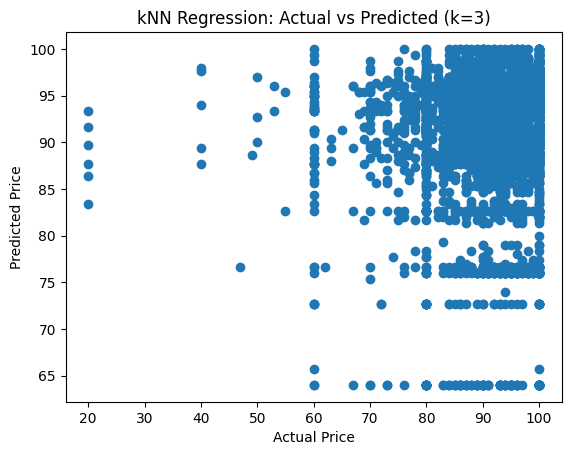

k=3, MSE=110.14233677493907


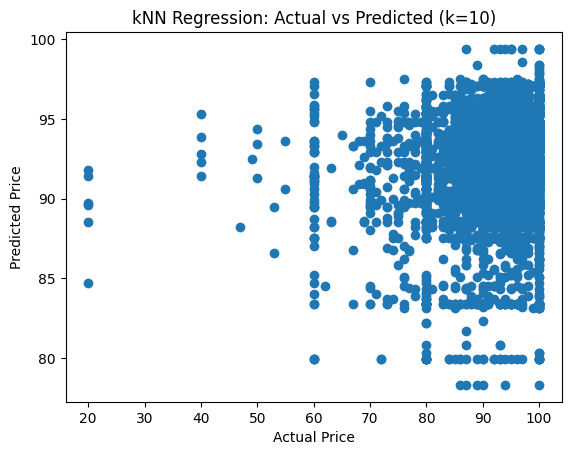

k=10, MSE=78.45593036400632


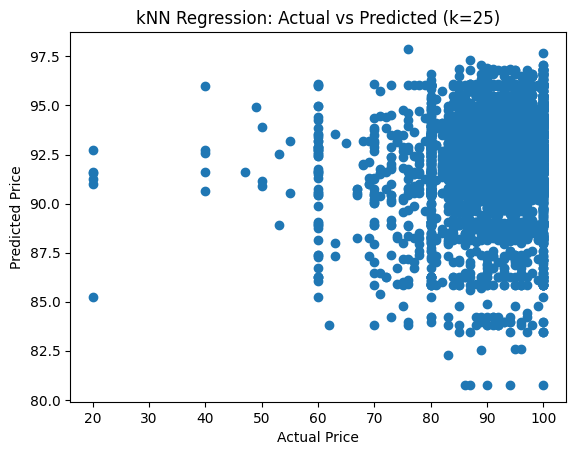

k=25, MSE=74.08435830884015


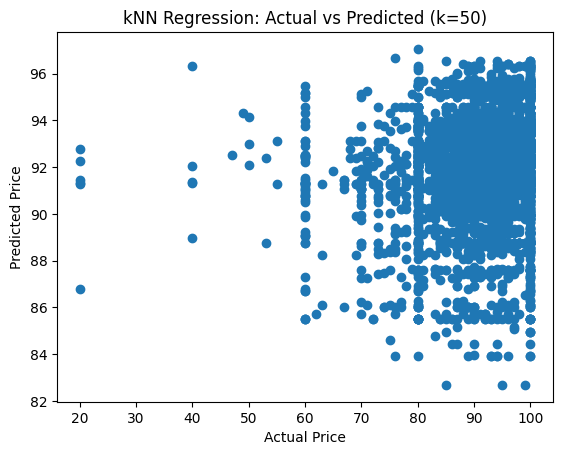

k=50, MSE=72.71399059461903


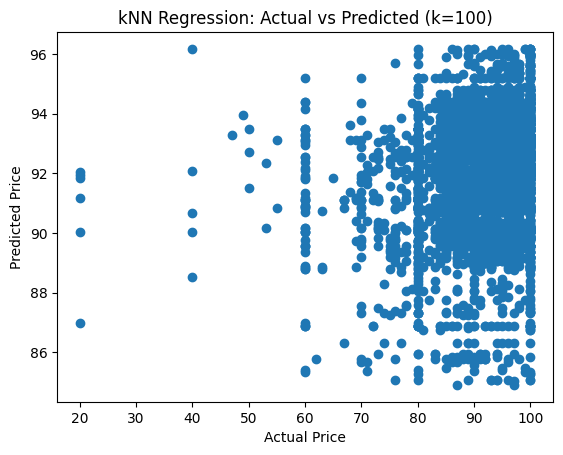

k=100, MSE=71.43827273343884


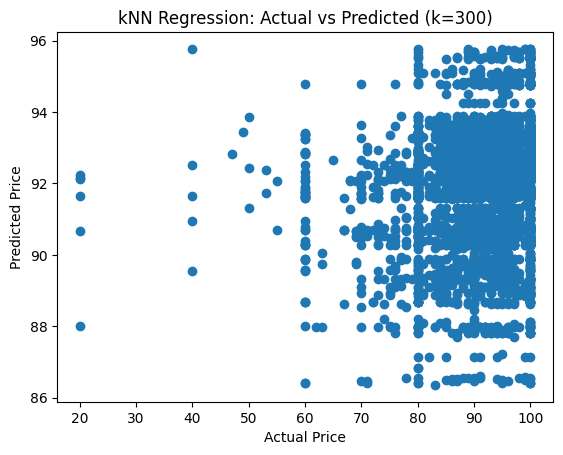

k=300, MSE=71.30981051573843


In [42]:
#Q3.4

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3,10,25,50,100,300]
mse_results = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[k] = mse
    plt.figure()
    plt.scatter(y_test, preds)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"kNN Regression: Actual vs Predicted (k={k})")
    plt.show()
    print(f"k={k}, MSE={mse}")

In [41]:
#Q3.5

best_k = min(mse_results, key=mse_results.get)
print("Optimal k:", best_k)
print("Minimum MSE:", mse_results[best_k])

Optimal k: 100
Minimum MSE: 71.43827273343884


**Q3.6:** As k increases, the predictions become smoother and less sensitive to individual observations. When k is very small, the model overfits, producing predictions that closely follow noise and appear highly scattered. When k is very large, the model underfits, producing overly smoothed predictions that cluster toward the average price. The optimal k balances overfitting and underfitting, resulting in predictions that track the actual prices without excessive noise or excessive smoothing.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [28]:
#Q6.1

df = pd.read_csv("data/airbnb_hw.csv")
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]
print(df.head())
print(df.shape)

   Review Scores Rating Price  Beds
0                   NaN   145   1.0
1                   NaN    37   1.0
2                   NaN    28   1.0
3                   NaN   199   3.0
4                  96.0   549   3.0
(30478, 3)


In [29]:
#Q6.2

missing_df = df.loc[df["Review Scores Rating"].isnull()].copy()
print(missing_df.shape)

(8323, 3)


In [35]:
#Q6.3

df = df.dropna(axis=0, how="any")
print(df.shape)

(22111, 3)


In [37]:
#Q6.4

df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Beds"] = pd.to_numeric(df["Beds"], errors="coerce")

df = df.dropna(axis=0, how="any")

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X = df[["Price", "Beds"]]
y = df["Review Scores Rating"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

k_values = [3,5,10,25,50,100]
mse_results = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[k] = mse
    print(f"k={k}, MSE={mse}")

best_k = min(mse_results, key=mse_results.get)
print("Optimal k:", best_k)

best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)

k=3, MSE=110.14233677493907
k=5, MSE=91.54437259778432
k=10, MSE=78.45593036400632
k=25, MSE=74.08435830884015
k=50, MSE=72.71399059461903
k=100, MSE=71.43827273343884
Optimal k: 100


KNeighborsRegressor(n_neighbors=100)

In [39]:
#Q6.5

missing_features = missing_df[["Price", "Beds"]].copy()

missing_features["Price"] = (
    missing_features["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
missing_features["Price"] = pd.to_numeric(missing_features["Price"], errors="coerce")
missing_features["Beds"] = pd.to_numeric(missing_features["Beds"], errors="coerce")

missing_features = missing_features.dropna(axis=0, how="any")

missing_scaled = scaler.transform(missing_features[["Price", "Beds"]])
missing_predictions = best_model.predict(missing_scaled)

missing_imputed = missing_df.loc[missing_features.index].copy()
missing_imputed["Imputed Review Score"] = missing_predictions

print(missing_imputed.head())
print(missing_imputed.shape)

    Review Scores Rating Price  Beds  Imputed Review Score
0                    NaN   145   1.0                 93.66
1                    NaN    37   1.0                 88.22
2                    NaN    28   1.0                 86.74
3                    NaN   199   3.0                 88.85
13                   NaN    68   1.0                 91.72
(8282, 4)


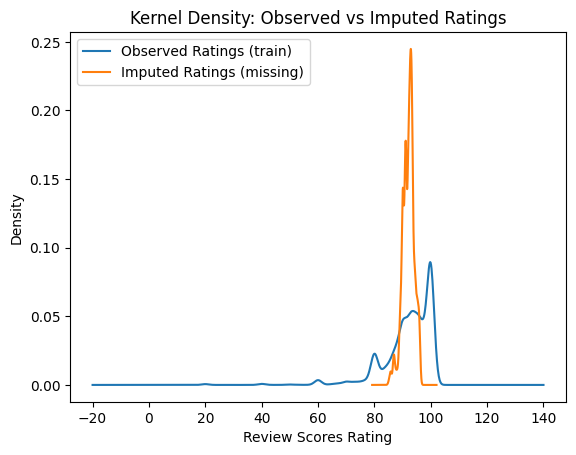

In [40]:
#Q6.6

plt.figure()
pd.Series(y_train).plot(kind="kde", label="Observed Ratings (train)")
missing_imputed["Imputed Review Score"].plot(kind="kde", label="Imputed Ratings (missing)")
plt.legend()
plt.title("Kernel Density: Observed vs Imputed Ratings")
plt.xlabel("Review Scores Rating")
plt.show()

They should look broadly similar, but the imputed distribution is usually a bit more “smoothed” and concentrated around the mean because kNN predicts by averaging nearby observations. Since, the imputed curve is much narrower, that suggests the missing cases differ systematically.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)